<a href="https://colab.research.google.com/github/Ali101050/European-options/blob/main/Black_Scholes_Implementation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import importlib.util, subprocess, sys
needed = {'numpy':'numpy', 'pandas':'pandas', 'matplotlib':'matplotlib'}
missing = [pkg for mod,pkg in needed.items() if importlib.util.find_spec(mod) is None]
if missing: subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
print('Required analysis libraries available.')

Required analysis libraries available.


In [ ]:
from pathlib import Path
import os
import sys
import zipfile
from google.colab import drive

drive.mount("/content/drive")

ROOT = Path("/content/colab_study")
ZIP_PATH = Path("/content/drive/MyDrive/study_files.zip")

if not ZIP_PATH.is_file():
    raise FileNotFoundError(f"ZIP not found at {ZIP_PATH}. Check its location in Drive.")

ROOT.mkdir(exist_ok=True)

with zipfile.ZipFile(ZIP_PATH) as archive:
    archive.extractall(ROOT)

sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

print("Extracted source and data to:", ROOT)

Mounted at /content/drive
Extracted source and data to: /content/colab_study


In [ ]:
result = subprocess.run([sys.executable, '-m', 'unittest', '-v'], cwd=ROOT, capture_output=True, text=True)
print(result.stdout + result.stderr)
if result.returncode: raise RuntimeError('Validation tests failed')

test_degenerate_limits (test_black_scholes.PricingTests.test_degenerate_limits) ... ok
test_greeks_finite_differences (test_black_scholes.PricingTests.test_greeks_finite_differences) ... ok
test_implied_volatility (test_black_scholes.PricingTests.test_implied_volatility) ... ok
test_invalid_inputs (test_black_scholes.PricingTests.test_invalid_inputs) ... ok
test_known_values (test_black_scholes.PricingTests.test_known_values) ... ok
test_monotonicity (test_black_scholes.PricingTests.test_monotonicity) ... ok
test_parity_and_bounds_grid (test_black_scholes.PricingTests.test_parity_and_bounds_grid) ... ok
test_simulation_reproducibility (test_black_scholes.PricingTests.test_simulation_reproducibility) ... ok
test_tree_accuracy (test_black_scholes.PricingTests.test_tree_accuracy) ... ok
test_am_settlement (test_empirical.EmpiricalTests.test_am_settlement) ... ok
test_bootstrap_reproducible (test_empirical.EmpiricalTests.test_bootstrap_reproducible) ... ok
test_current_return_is_excluded (

In [ ]:
"""European vanilla options under constant-volatility geometric Brownian motion.
Rates and volatility are decimals; time is in years; prices are per underlying unit.
Only the standard library is needed. Greeks are per unit rate/volatility change.
"""
import argparse
import json
import math
import random
from dataclasses import dataclass, asdict

@dataclass(frozen=True)
class Inputs:
    spot: float
    strike: float
    time: float
    rate: float
    volatility: float
    dividend: float = 0.0

    def __post_init__(self):
        for name, value in asdict(self).items():
            if isinstance(value, bool) or not isinstance(value, (int, float)) or not math.isfinite(value):
                raise ValueError(f'{name} must be a finite number')
        if self.spot <= 0 or self.strike <= 0:
            raise ValueError('spot and strike must be positive')
        if self.time < 0 or self.volatility < 0:
            raise ValueError('time and volatility must be nonnegative')


def _kind(kind):
    if kind not in ('call', 'put'):
        raise ValueError("kind must be 'call' or 'put'")


def cdf(x):
    return 0.5 * math.erfc(-x / math.sqrt(2))


def price(p, kind='call'):
    """Return a Black-Scholes-Merton price, including expiry and zero-vol limits."""
    _kind(kind)
    a = p.spot * math.exp(-p.dividend * p.time)
    b = p.strike * math.exp(-p.rate * p.time)
    if p.time == 0 or p.volatility == 0:
        return max(a-b, 0.0) if kind == 'call' else max(b-a, 0.0)
    v = p.volatility * math.sqrt(p.time)
    d1 = (math.log(p.spot / p.strike) + (p.rate-p.dividend+0.5*p.volatility**2)*p.time)/v
    d2 = d1-v
    # Evaluate the out-of-the-money side directly to reduce cancellation.
    if a <= b:
        call = max(0.0, a*cdf(d1)-b*cdf(d2))
        return call if kind == 'call' else call+b-a
    put = max(0.0, b*cdf(-d2)-a*cdf(-d1))
    return put+a-b if kind == 'call' else put


def greeks(p, kind='call'):
    """Theta is calendar-time decay per year; vega/rho are per change of 1.0.
    Degenerate Greeks are deliberately rejected because of boundary conventions.
    """
    _kind(kind)
    if p.time == 0 or p.volatility == 0:
        raise ValueError('Greeks require positive time and volatility')
    t, s, k, r, q, v = p.time, p.spot, p.strike, p.rate, p.dividend, p.volatility
    root = math.sqrt(t)
    d1 = (math.log(s/k)+(r-q+v*v/2)*t)/(v*root)
    d2 = d1-v*root
    eq, er = math.exp(-q*t), math.exp(-r*t)
    density = math.exp(-d1*d1/2)/math.sqrt(2*math.pi)
    z = 1 if kind == 'call' else -1
    return dict(delta=z*eq*cdf(z*d1), gamma=eq*density/(s*v*root),
                vega=s*eq*density*root,
                theta=-s*eq*density*v/(2*root)-z*r*k*er*cdf(z*d2)+z*q*s*eq*cdf(z*d1),
                rho=z*k*t*er*cdf(z*d2))


def implied_volatility(p, target, kind='call', tolerance=1e-10, max_iterations=200):
    """Bisection inversion. A price equal to its lower bound returns zero.
    The unattainable upper bound is rejected; expiry cannot identify volatility.
    """
    _kind(kind)
    if p.time == 0:
        raise ValueError('volatility is not identifiable at expiry')
    if not math.isfinite(target) or tolerance <= 0 or not math.isfinite(tolerance):
        raise ValueError('finite target and positive finite tolerance required')
    if not isinstance(max_iterations, int) or max_iterations < 1:
        raise ValueError('max_iterations must be a positive integer')
    a, b = p.spot*math.exp(-p.dividend*p.time), p.strike*math.exp(-p.rate*p.time)
    lower, upper = (max(a-b, 0), a) if kind == 'call' else (max(b-a, 0), b)
    if target < lower or target >= upper:
        raise ValueError('target lies outside finite-volatility price bounds')
    if target == lower:
        return 0.0
    def value(v):
        return price(Inputs(p.spot,p.strike,p.time,p.rate,v,p.dividend),kind)
    low, high = 0.0, 1.0
    while value(high) < target:
        high *= 2
        if high > 1024:
            raise ValueError('unable to bracket volatility')
    for _ in range(max_iterations):
        mid = (low+high)/2
        error = value(mid)-target
        if abs(error) <= tolerance:
            return mid
        if error < 0: low = mid
        else: high = mid
    raise RuntimeError('implied volatility did not converge')


def binomial(p, kind='call', steps=500):
    """European Cox-Ross-Rubinstein backward induction, O(steps^2) time."""
    _kind(kind)
    if isinstance(steps,bool) or not isinstance(steps,int) or steps < 1:
        raise ValueError('steps must be a positive integer')
    if p.time == 0 or p.volatility == 0:
        return price(p,kind)
    dt = p.time/steps
    u = math.exp(p.volatility*math.sqrt(dt))
    d = 1/u
    prob = (math.exp((p.rate-p.dividend)*dt)-d)/(u-d)
    if not 0 <= prob <= 1:
        raise ValueError('invalid tree probability; increase steps')
    z = 1 if kind == 'call' else -1
    values = [max(z*(p.spot*math.exp((2*j-steps)*math.log(u))-p.strike),0) for j in range(steps+1)]
    discount = math.exp(-p.rate*dt)
    for n in range(steps,0,-1):
        values = [discount*(prob*values[j+1]+(1-prob)*values[j]) for j in range(n)]
    return values[0]


def monte_carlo(p, kind='call', samples=100000, seed=42):
    """Exact terminal GBM sampling; normal-approximation 95% confidence interval."""
    _kind(kind)
    if isinstance(samples,bool) or not isinstance(samples,int) or samples < 2:
        raise ValueError('samples must be an integer >= 2')
    if p.time == 0 or p.volatility == 0:
        value=price(p,kind)
        return dict(estimate=value, standard_error=0.0, ci95=[value,value], samples=samples,seed=seed)
    rng = random.Random(seed)
    mean = m2 = 0.0
    sign = 1 if kind == 'call' else -1
    for n in range(1,samples+1):
        terminal=p.spot*math.exp((p.rate-p.dividend-p.volatility**2/2)*p.time+p.volatility*math.sqrt(p.time)*rng.gauss(0,1))
        value=math.exp(-p.rate*p.time)*max(sign*(terminal-p.strike),0)
        delta=value-mean
        mean += delta/n
        m2 += delta*(value-mean)
    se=math.sqrt(m2/(samples-1)/samples)
    return dict(estimate=mean,standard_error=se,ci95=[mean-1.96*se,mean+1.96*se],samples=samples,seed=seed)

In [ ]:
from pathlib import Path
from datetime import datetime,time,timezone
from zoneinfo import ZoneInfo
import argparse,json,math,hashlib,platform
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from black_scholes import Inputs,price,implied_volatility,greeks,binomial,monte_carlo

NY=ZoneInfo('America/New_York')
CUTOFF=pd.Timestamp('2026-09-08')

In [ ]:
def features(underlying,rates):
    """Daily features: volatility and rate use only dates strictly before valuation."""
    u=underlying.copy().sort_values('date').drop_duplicates('date')
    u['date']=pd.to_datetime(u['date'])
    u=u[u.close.notna() & (u.close>0)].copy()
    ret=np.log(u.close/u.close.shift(1))
    u['log_return']=ret
    for n in (20,60):u[f'hv{n}']=ret.rolling(n,min_periods=n).std(ddof=1).shift(1)*np.sqrt(252)
    rr=rates.copy();rr['date']=pd.to_datetime(rr['date']);rr=rr[rr.close.notna()].sort_values('date')
    # Treat IRX as a bank-discount quotation, approximate remaining bill maturity 91d.
    rr['rate']=-365/91*np.log(1-(rr.close/100)*91/360)
    rr=rr.rename(columns={'date':'rate_source_date'})
    u=pd.merge_asof(u,rr[['rate_source_date','rate']],left_on='date',right_on='rate_source_date',direction='backward',allow_exact_matches=False)
    return u

In [ ]:
def maturity(date,expiry,settlement='AM'):
    """ACT/365 from valuation 16:00 New York to AM 09:30 or PM 16:00 settlement."""
    start=datetime.combine(pd.Timestamp(date).date(),time(16),NY)
    end=datetime.combine(pd.Timestamp(expiry).date(),time(9,30) if settlement=='AM' else time(16),NY)
    return (end.astimezone(timezone.utc)-start.astimezone(timezone.utc)).total_seconds()/(365*86400)

In [ ]:
def metrics(frame,column):
    x=frame[['close',column]].replace([np.inf,-np.inf],np.nan).dropna()
    if len(x)==0:return {'n':0,'mae':None,'rmse':None,'bias':None,'wape_pct':None,'median_ae':None}
    e=x[column]-x.close
    return dict(n=len(x),mae=float(e.abs().mean()),rmse=float(np.sqrt((e*e).mean())),bias=float(e.mean()),wape_pct=float(100*e.abs().sum()/x.close.abs().sum()) if x.close.abs().sum()>0 else None,median_ae=float(e.abs().median()))

In [ ]:
def block_bootstrap(frame,replicates=2000,seed=17,block=5):
    """Paired HV60 minus HV20 MAE; blocks of contiguous observed trading dates."""
    dates=sorted(frame.date.unique());rng=np.random.default_rng(seed)
    losses=frame.assign(loss=(frame.pred_hv60-frame.close).abs()-(frame.pred_hv20-frame.close).abs()).groupby('date').loss.agg(['sum','count']).reindex(dates)
    vals=[];n=len(dates)
    if n<block:return None
    for _ in range(replicates):
        idx=[]
        while len(idx)<n:
            start=int(rng.integers(0,n-block+1));idx.extend(range(start,start+block))
        y=losses.iloc[idx[:n]];vals.append(float(y['sum'].sum()/y['count'].sum()))
    return dict(difference=float(losses['sum'].sum()/losses['count'].sum()),ci95=[float(x) for x in np.quantile(vals,[.025,.975])],replicates=replicates,block_dates=block,seed=seed)

In [ ]:
def analyze(root):
    root=Path(root);out=root/'results';figs=root/'figures';out.mkdir(exist_ok=True);figs.mkdir(exist_ok=True)
    u=pd.read_csv(root/'data/underlying.csv');r=pd.read_csv(root/'data/rates.csv');opts=pd.read_csv(root/'data/options.csv')
    opts['date']=pd.to_datetime(opts.date);opts['expiry']=pd.to_datetime(opts.expiry)
    feat=features(u,r);feat.to_csv(out/'daily_features.csv',index=False)
    d=opts.merge(feat[['date','close','hv20','hv60','rate','rate_source_date']],on='date',suffixes=('','_spot'),how='left').rename(columns={'close_spot':'spot'})
    d['time']=[maturity(a,b,c) for a,b,c in zip(d.date,d.expiry,d.settlement)]
    d['q']=.01
    d['exclusion_reason']=''
    d.loc[d.time<=0,'exclusion_reason']='nonpositive maturity'
    d.loc[d.close.isna() | (d.close<=0),'exclusion_reason']='missing or nonpositive option close'
    d.loc[d[['spot','hv20','hv60','rate']].isna().any(axis=1),'exclusion_reason']='missing lagged features or spot'
    rejected=d[d.exclusion_reason!=''].copy();rejected.to_csv(out/'excluded_rows.csv',index=False)
    d=d[d.exclusion_reason==''].copy().sort_values(['contract','date'])
    predictions=[]
    for row in d.itertuples():
        p=Inputs(row.spot,row.strike,row.time,row.rate,row.hv20,row.q)
        a=row.spot*math.exp(-row.q*row.time);b=row.strike*math.exp(-row.rate*row.time)
        lower,upper=(max(a-b,0),a) if row.kind=='call' else (max(b-a,0),b)
        valid=lower<=row.close<upper
        iv=np.nan
        if valid:
            try:iv=implied_volatility(p,row.close,row.kind,tolerance=1e-8)
            except (ValueError,RuntimeError):pass
        vals=dict(pred_hv20=price(p,row.kind),pred_hv60=price(Inputs(row.spot,row.strike,row.time,row.rate,row.hv60,row.q),row.kind),iv=iv,lower_bound=lower,upper_bound=upper,bounds_valid=valid,vega=greeks(p,row.kind)['vega'])
        for label,q in [('q0',0),('q2',.02)]:vals['pred_'+label]=price(Inputs(row.spot,row.strike,row.time,row.rate,row.hv20,q),row.kind)
        for label,mul in [('vol80',.8),('vol120',1.2)]:vals['pred_'+label]=price(Inputs(row.spot,row.strike,row.time,row.rate,row.hv20*mul,row.q),row.kind)
        for label,dr in [('rminus',-.01),('rplus',.01)]:vals['pred_'+label]=price(Inputs(row.spot,row.strike,row.time,row.rate+dr,row.hv20,row.q),row.kind)
        predictions.append(vals)
    d=pd.concat([d.reset_index(drop=True),pd.DataFrame(predictions)],axis=1)
    d['lag_iv']=d.groupby('contract').iv.shift(1)
    d['lag_iv_date']=d.groupby('contract').date.shift(1)
    d['lag_gap_days']=(d.date-d.lag_iv_date).dt.days
    d.loc[d.lag_gap_days>7,'lag_iv']=np.nan
    d['pred_lag_iv']=[price(Inputs(x.spot,x.strike,x.time,x.rate,x.lag_iv,x.q),x.kind) if pd.notna(x.lag_iv) else np.nan for x in d.itertuples()]
    d['dte']=d.time*365;d['moneyness']=d.spot/d.strike
    d['split']=np.where(d.date<CUTOFF,'earlier','holdout')
    d['screened']=(d.volume>=10)&(d.close>=1)&(d.dte>=7)
    for m in ('hv20','hv60','lag_iv'):d['error_'+m]=d['pred_'+m]-d.close
    d.to_csv(out/'priced_observations.csv',index=False)
    output=[]
    groups={'all':d,'earlier':d[d.split=='earlier'],'holdout':d[d.split=='holdout'],'screened':d[d.screened],'screened_holdout':d[d.screened & (d.split=='holdout')],'common_iv_sample':d[d.pred_lag_iv.notna()],'common_iv_holdout':d[(d.split=='holdout') & d.pred_lag_iv.notna()],'calls':d[d.kind=='call'],'puts':d[d.kind=='put']}
    for group,frame in groups.items():
        for model in ('hv20','hv60','lag_iv'):output.append(dict(group=group,model=model,**metrics(frame,'pred_'+model)))
    ms=pd.DataFrame(output);ms.to_csv(out/'metrics.csv',index=False)
    per=[]
    for contract,x in d.groupby('contract'):
        for m in ('hv20','hv60','lag_iv'):per.append(dict(contract=contract,model=m,**metrics(x,'pred_'+m)))
    pd.DataFrame(per).to_csv(out/'metrics_by_contract.csv',index=False)
    sensitivity=pd.DataFrame([dict(variant=x,**metrics(d,'pred_'+x)) for x in ('hv20','q0','q2','vol80','vol120','rminus','rplus')]);sensitivity.to_csv(out/'sensitivity.csv',index=False)
    pairs=d.pivot_table(index=['date','expiry','strike'],columns='kind',values='close').dropna(subset=['call','put']).reset_index()
    pairfeat=feat[['date','close','rate']].rename(columns={'close':'spot'})
    pairs=pairs.merge(pairfeat,on='date');pairs['time']=[maturity(a,b) for a,b in zip(pairs.date,pairs.expiry)]
    pairs['parity_residual']=pairs.call-pairs.put-(pairs.spot*np.exp(-.01*pairs.time)-pairs.strike*np.exp(-pairs.rate*pairs.time))
    pairs.to_csv(out/'parity_diagnostics.csv',index=False)
    summary=dict(raw_option_rows=len(opts),priced_rows=len(d),excluded_rows=len(rejected),contracts=int(d.contract.nunique()),trading_dates=int(d.date.nunique()),date_start=str(d.date.min().date()),date_end=str(d.date.max().date()),holdout_start=str(CUTOFF.date()),holdout_rows=int((d.split=='holdout').sum()),screened_rows=int(d.screened.sum()),invalid_bounds_rows=int((~d.bounds_valid).sum()),available_lag_iv_rows=int(d.pred_lag_iv.notna().sum()),q_assumption=.01,hv20_range=[float(d.hv20.min()),float(d.hv20.max())],hv60_range=[float(d.hv60.min()),float(d.hv60.max())],rate_range=[float(d.rate.min()),float(d.rate.max())],dte_range=[float(d.dte.min()),float(d.dte.max())],volume_below10=int((d.volume<10).sum()),missing_volume=int(d.volume.isna().sum()),parity_pairs=len(pairs),parity_mae=float(pairs.parity_residual.abs().mean()),parity_max_abs=float(pairs.parity_residual.abs().max()),bootstrap_all=block_bootstrap(d),bootstrap_holdout=block_bootstrap(d[d.split=='holdout']),python=platform.python_version(),numpy=np.__version__,pandas=pd.__version__,execution='Local Python execution of the same portable analysis module delivered for Colab; no hosted Colab execution claimed.')
    baseline=Inputs(100,100,1,.05,.2);summary['numerical_validation']={'analytical_call':price(baseline),'analytical_put':price(baseline,'put'),'binomial_1000':binomial(baseline,steps=1000),'monte_carlo_100000':monte_carlo(baseline,samples=100000,seed=42)}
    (out/'summary.json').write_text(json.dumps(summary,indent=2,allow_nan=False))
    # Exact outputs, all saved as publication-quality PNGs.
    plt.rcParams.update({'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
    fig,ax=plt.subplots(figsize=(7,3.7));v=feat[(feat.date>=pd.Timestamp('2026-07-01'))&(feat.date<=pd.Timestamp('2026-09-30'))];ax.plot(v.date,v.hv20*100,label='HV20');ax.plot(v.date,v.hv60*100,label='HV60');ax.set(ylabel='Annual volatility (%)',title='Lagged historical volatility inputs');ax.legend();fig.autofmt_xdate();fig.tight_layout();fig.savefig(figs/'volatility.png',dpi=200);plt.close(fig)
    fig,axs=plt.subplots(1,2,figsize=(8,3.8))
    for ax,m in zip(axs,('hv20','hv60')):
        for kind,mark in [('call','o'),('put','^')]:
            x=d[d.kind==kind];ax.scatter(x.close,x['pred_'+m],s=13,alpha=.45,marker=mark,label=kind)
        limit=max(d.close.max(),d['pred_'+m].max());ax.plot([0,limit],[0,limit],'k--',linewidth=1);ax.set(xlabel='Observed daily option close (points)',ylabel='Model price (points)',title=m.upper());ax.legend()
    fig.tight_layout();fig.savefig(figs/'predicted_actual.png',dpi=200);plt.close(fig)
    daily=d.groupby('date')[['error_hv20','error_hv60']].mean();fig,ax=plt.subplots(figsize=(7,3.7));ax.plot(daily.index,daily.error_hv20,label='HV20');ax.plot(daily.index,daily.error_hv60,label='HV60');ax.axhline(0,color='black',lw=.8);ax.axvline(CUTOFF,color='gray',ls=':',label='Holdout starts');ax.set(ylabel='Mean pricing error (points)',title='Daily mean signed errors');ax.legend();fig.autofmt_xdate();fig.tight_layout();fig.savefig(figs/'daily_errors.png',dpi=200);plt.close(fig)
    chosen=d[d.contract=='SPX261016P07600000'];fig,ax=plt.subplots(figsize=(7,3.7));ax.plot(chosen.date,chosen.close,'k-',label='Observed close');ax.plot(chosen.date,chosen.pred_hv20,label='HV20');ax.plot(chosen.date,chosen.pred_hv60,label='HV60');ax.plot(chosen.date,chosen.pred_lag_iv,alpha=.8,label='Prior observed IV');ax.set(ylabel='Option price (points)',title='16 October 2026 SPX put, strike 7600');ax.legend();fig.autofmt_xdate();fig.tight_layout();fig.savefig(figs/'contract_path.png',dpi=200);plt.close(fig)
    fig,ax=plt.subplots(figsize=(7,3.7));ax.scatter(d.moneyness,d.iv*100,c=d.dte,s=14,alpha=.6,cmap='viridis');ax.set(xlabel='Spot / strike',ylabel='Same-observation implied volatility (%)',title='Implied volatility diagnostic');norm=plt.Normalize(d.dte.min(),d.dte.max());fig.colorbar(plt.cm.ScalarMappable(norm=norm,cmap='viridis'),ax=ax,label='Days to AM settlement');fig.tight_layout();fig.savefig(figs/'implied_volatility.png',dpi=200);plt.close(fig)
    fig,ax=plt.subplots(figsize=(7,3.7));ax.bar(sensitivity.variant,sensitivity.mae,color='#315978');ax.set(ylabel='MAE (points)',title='Sensitivity of full-sample HV20 pricing error');ax.tick_params(axis='x',rotation=25);fig.tight_layout();fig.savefig(figs/'sensitivity.png',dpi=200);plt.close(fig)
    print(json.dumps(summary,indent=2));print(ms.to_string(index=False));return d,ms,summary

In [ ]:
observations, metrics, summary = analyze(ROOT)

{
  "raw_option_rows": 738,
  "priced_rows": 738,
  "excluded_rows": 0,
  "contracts": 12,
  "trading_dates": 64,
  "date_start": "2026-07-01",
  "date_end": "2026-09-30",
  "holdout_start": "2026-09-08",
  "holdout_rows": 199,
  "screened_rows": 606,
  "invalid_bounds_rows": 2,
  "available_lag_iv_rows": 724,
  "q_assumption": 0.01,
  "hv20_range": [
    0.07367486433677307,
    0.17771321457160708
  ],
  "hv60_range": [
    0.10949869839681245,
    0.1406918250018955
  ],
  "rate_range": [
    0.03726058928304341,
    0.04147901649369726
  ],
  "dte_range": [
    15.729166666666668,
    169.77083333333334
  ],
  "volume_below10": 132,
  "missing_volume": 0,
  "parity_pairs": 354,
  "parity_mae": 14.163364961605568,
  "parity_max_abs": 93.63449457309974,
  "bootstrap_all": {
    "difference": -14.60939511502076,
    "ci95": [
      -24.922473105355344,
      -6.3363986820828595
    ],
    "replicates": 2000,
    "block_dates": 5,
    "seed": 17
  },
  "bootstrap_holdout": {
    "diffe

In [ ]:
print(metrics[['group','model','n','mae','rmse','bias']].to_string(index=False))
print('Actual versus model values:')
print(observations[['date','contract','close','pred_hv20','pred_hv60','pred_lag_iv']].tail(12).to_string(index=False))

            group  model   n       mae      rmse       bias
              all   hv20 738 46.220349 55.842912 -39.253036
              all   hv60 738 31.610954 38.713236 -28.620797
              all lag_iv 724  6.882873 10.950165   0.404076
          earlier   hv20 539 45.168941 54.874614 -35.738778
          earlier   hv60 539 31.205430 38.325966 -27.478810
          earlier lag_iv 525  7.474142 11.910537   0.502317
          holdout   hv20 199 49.068132 58.384989 -48.771556
          holdout   hv60 199 32.709335 39.743224 -31.713916
          holdout lag_iv 199  5.322991  7.873070   0.144900
         screened   hv20 606 45.949070 55.564682 -40.387358
         screened   hv60 606 30.792439 37.553804 -28.089380
         screened lag_iv 599  6.532708 10.138695   0.328112
 screened_holdout   hv20 168 49.770084 59.023377 -49.418782
 screened_holdout   hv60 168 32.450650 39.314579 -31.350453
 screened_holdout lag_iv 168  5.464686  8.065464   0.532232
 common_iv_sample   hv20 724 46.350933 5

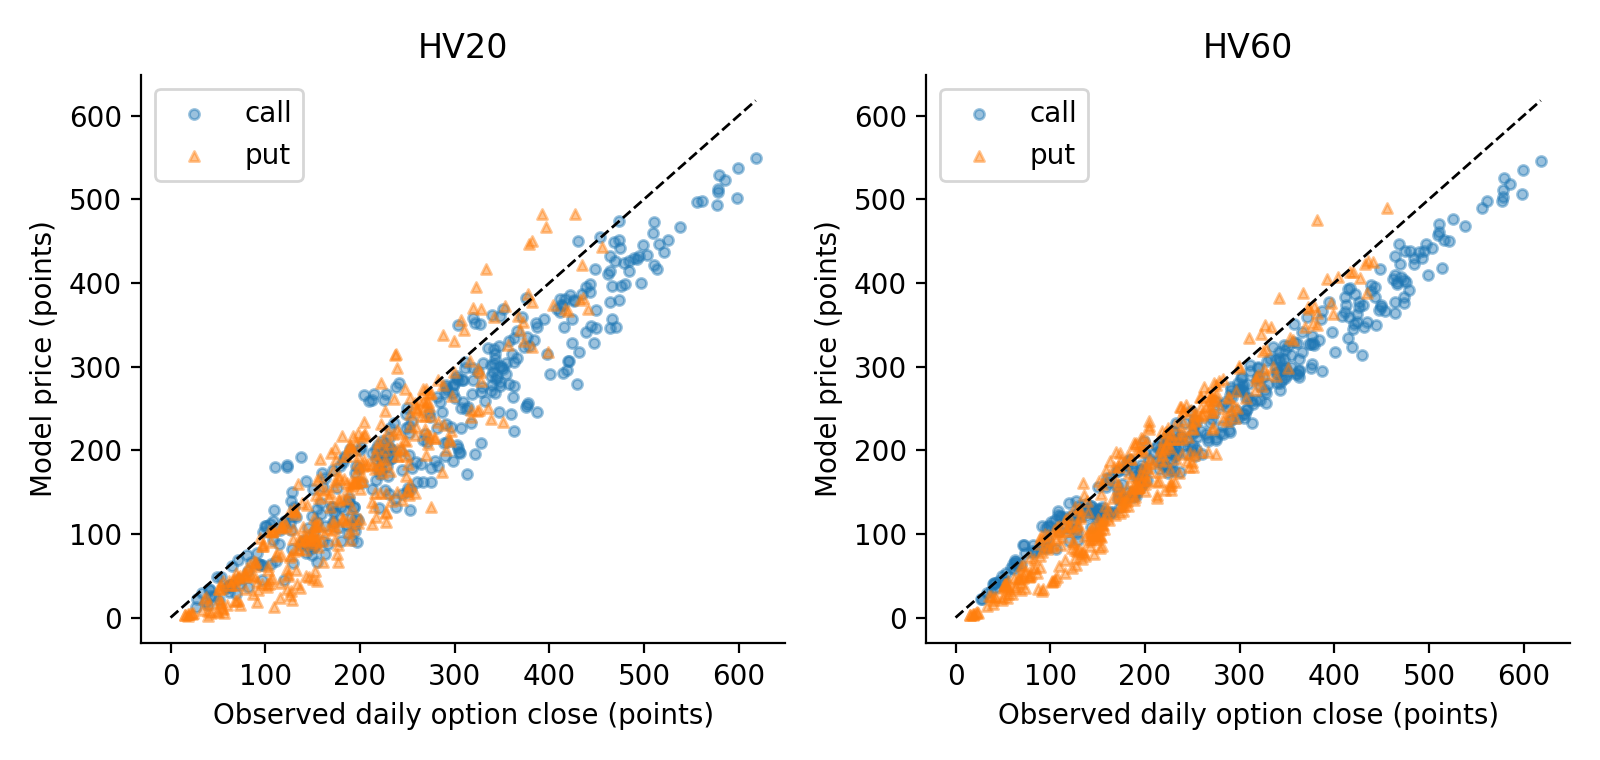

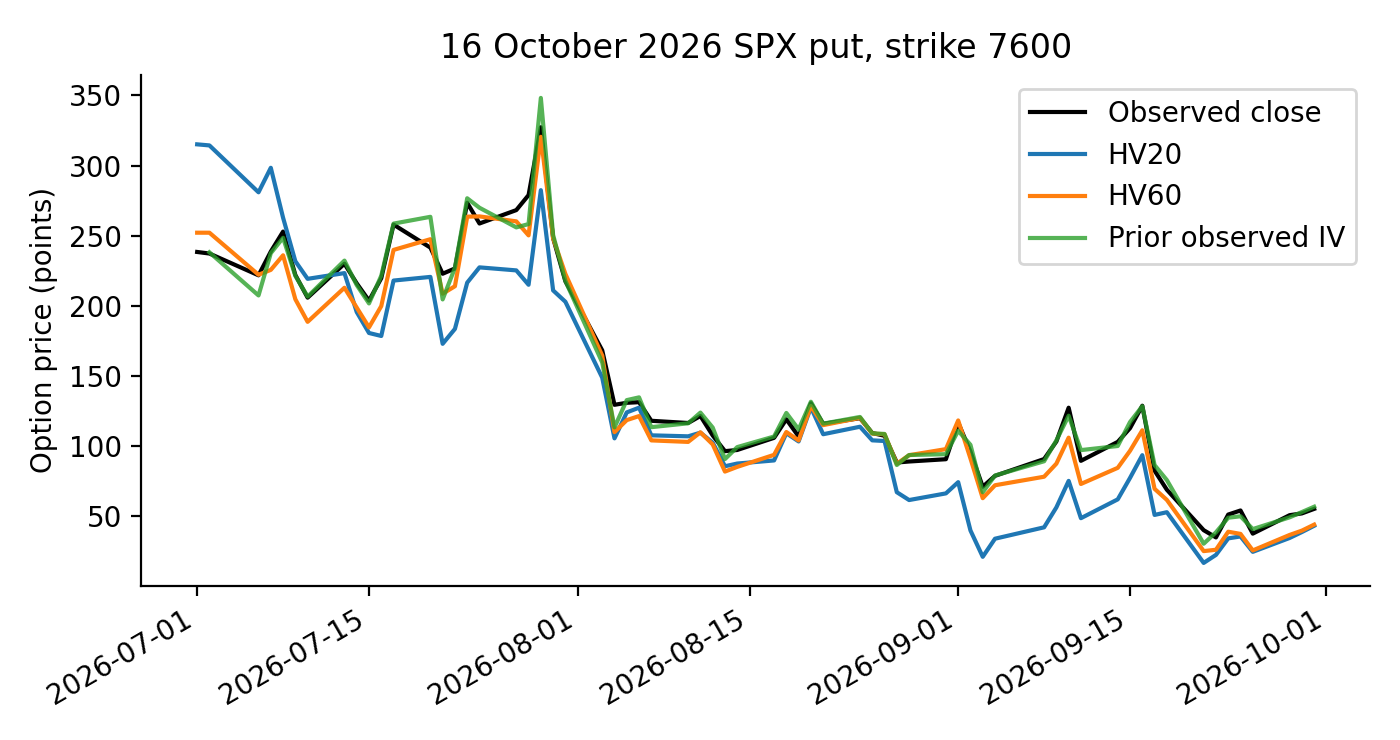

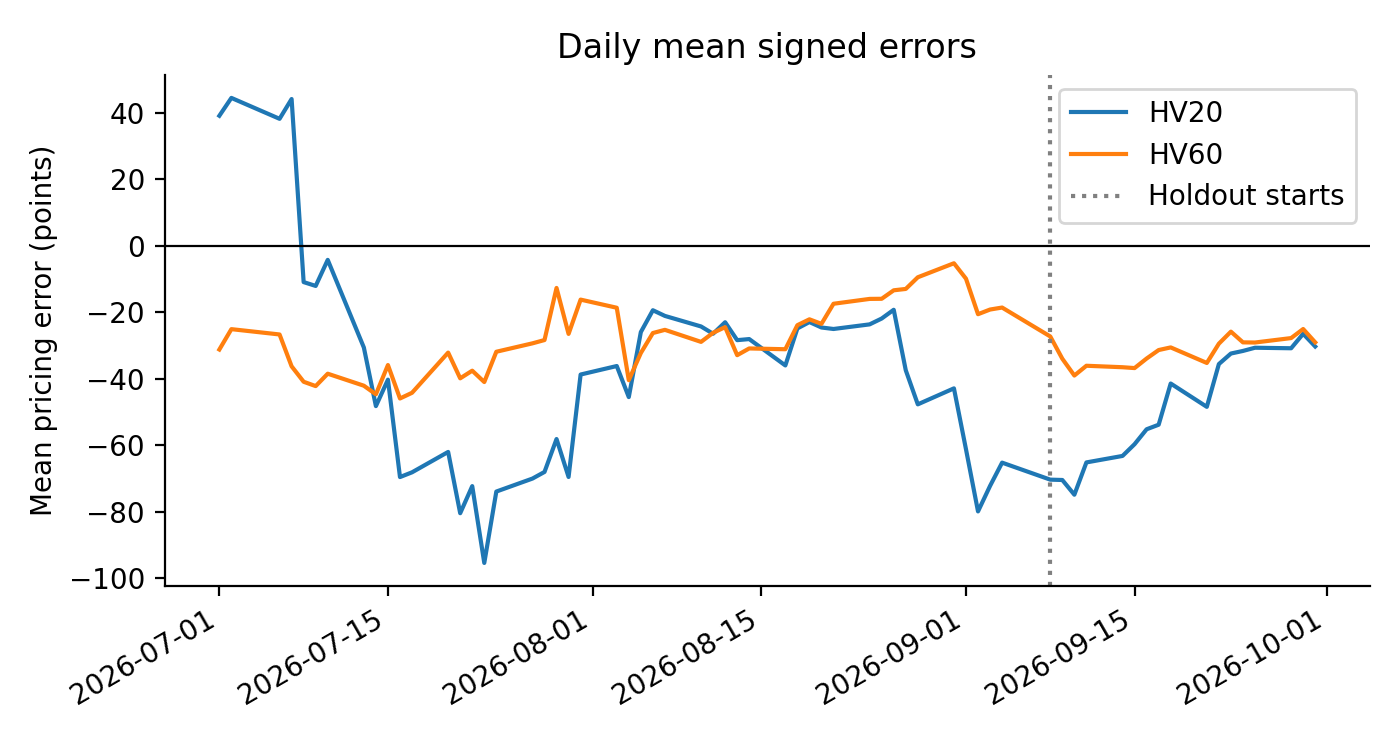

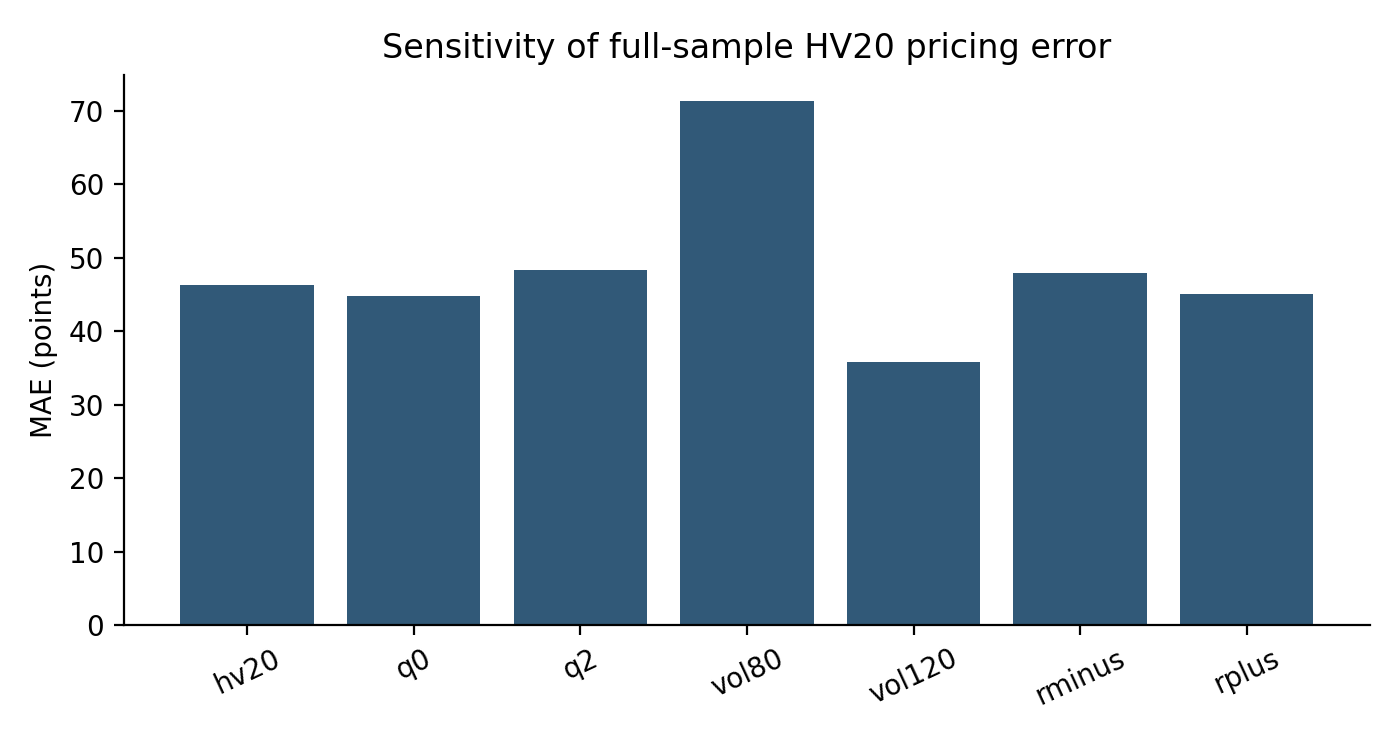

In [ ]:
try:
    from IPython.display import display, Image
except ImportError:
    display = lambda image: print(image)
    Image = lambda filename: filename
for name in ['predicted_actual.png','contract_path.png','daily_errors.png','sensitivity.png']:
    display(Image(filename=str(ROOT/'figures'/name)))